# (17) drifting grating w/ n_exp p = 1e-3, t_final = 0.01

project = ```iP-VAE```, host = ```chewie```, device = ```cuda:0```

**Motivation**: <br>

I was able to reproduce the results when I increases n_exp_p from 1e-6 to 1e-3. So I will go with 1e-3 from now on.

- Edit: I also experimented with a smaller final temperature (0.01 instead of 0.05) and it's better. So I'll go with 0.01 from now on.

In [1]:
# HIDE CODE


import os, sys
from IPython.display import display

# tmp & extras dir
git_dir = os.path.join(os.environ['HOME'], 'Dropbox/git')
extras_dir = os.path.join(git_dir, 'jb-progress-2025/_extras')
fig_base_dir = os.path.join(git_dir, 'jb-progress-2025/figs')
tmp_dir = os.path.join(git_dir, 'jb-progress-2025/tmp')

# GitHub
sys.path.insert(0, os.path.join(git_dir, '_IterativeVAE'))
from figures.analysis import plot_convergence
from figures.imgs import plot_weights
from figures.fighelper import *
from main.train import *

# warnings, tqdm, & style
warnings.filterwarnings('ignore', category=DeprecationWarning)
warnings.filterwarnings('ignore', category=FutureWarning)
warnings.filterwarnings('ignore', category=UserWarning)
from rich.jupyter import print
%matplotlib inline
set_style()

In [2]:
from utils.animation import show_movie


device_idx = 0
device = f'cuda:{device_idx}'

print(f"device: {device}  ———  host: {os.uname().nodename}")

device: cuda:0  ———  host: chewie

## Load trainer

In [3]:
# model_name = 'vH16_t-16_z-[512]_<grad|lin>'
# fit_name = 'nexp-(p:1e-3)_clamp-(u:8,du:7)_b200-ep300-lr(0.002)_beta(20:0.1)_temp(0.05:0.5)_gr(500)_(2025_02_17,15:17)'

model_name = 'vH16_t-16_z-[512]_cl-8,7_<grad|lin>'
fit_name = 'b200-ep300-lr(0.002)_beta(20:0.1)_temp(0.01:0.5)_gr(500)_(2025_02_18,09:37)'

tr, meta = load_model(f"{model_name}/{fit_name}", device)
meta['checkpoint']

300

### Make feeder

In [4]:
n_frames_for_full_cycle = 500
n_cycles_per_image = 4

feeder_kws = dict(
    npix=16,
    #
    theta=0.0,
    s_freq=n_cycles_per_image,
    t_freq=1 / n_frames_for_full_cycle,
    contrast=np.linspace(0.4, 1.0, 64),
    normalize_coords=True,
    #
    device=device,
    flatten=True,
)
feeder = FEEDER_CLASSES['drifting-grating'](**feeder_kws)

In [5]:
n_trials = 30
seq = range(n_frames_for_full_cycle * (n_trials + 1))

print(seq)

range(0, 15500)

### Xtract ftrs

In [6]:
%%time

output = tr.model.xtract_ftr(
    feeder=feeder,
    seq=seq,
    return_extras=True,
).stack()

CPU times: user 29.4 s, sys: 840 ms, total: 30.3 s
Wall time: 30.3 s


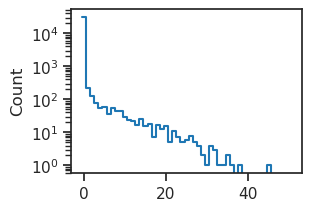

In [7]:
spks = tonp(output['samples'][:, -1].ravel()).astype(int)

fig, ax = create_figure()
histplot(spks, bins=np.linspace(0, 51, 52) - 0.5)
ax.set(yscale='log')
plt.show()

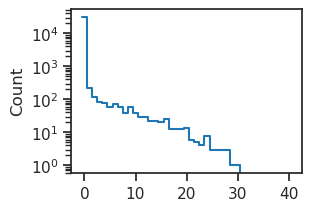

In [15]:
### Was: n_exp_p = 1e-6

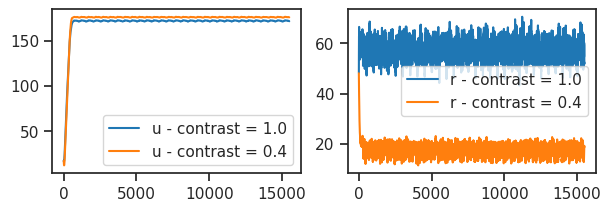

In [8]:
u_norm = tonp(torch.linalg.norm(output['u'], axis=-1))
v_norm = tonp(torch.linalg.norm(output['v'], axis=-1))
r_norm = tonp(torch.linalg.norm(torch.exp(output['u']), axis=-1))

fig, axes = create_figure(1, 2)
axes[0].plot(u_norm[-1], ls='-', label='u - contrast = 1.0')
axes[0].plot(u_norm[0], label='u - contrast = 0.4')
axes[1].plot(r_norm[-1], ls='-', label='r - contrast = 1.0')
axes[1].plot(r_norm[0], label='r - contrast = 0.4')

add_legend(axes)
plt.show()

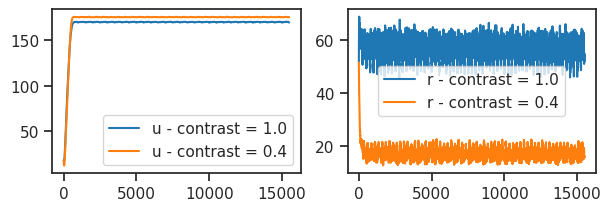

In [16]:
### Was: n_exp_p = 1e-6

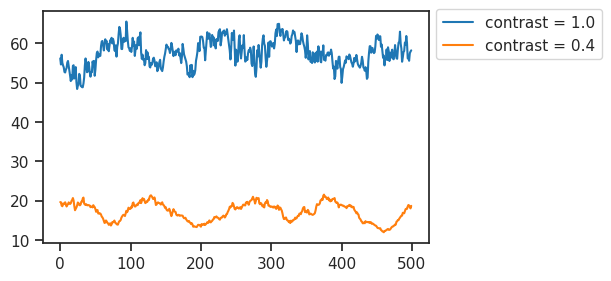

In [9]:
fig, ax = create_figure(1, 1, (6, 2.7))

intvl = range(1000, 1500)
ax.plot(r_norm[-1][intvl], ls='-', label='contrast = 1.0')
ax.plot(r_norm[0][intvl], label='contrast = 0.4')

add_legend(ax)
move_legend(ax, bbox=(1, 1.04))

plt.show()

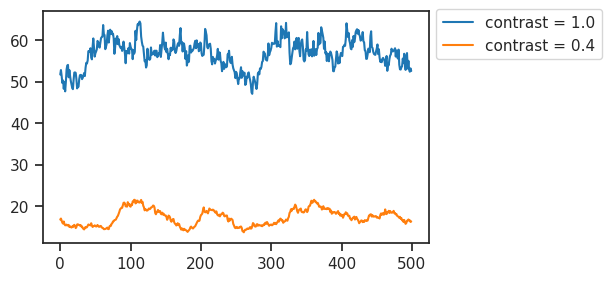

In [17]:
### Was: n_exp_p = 1e-6

### Most responsive neurons

In [10]:
firing_rates = torch.exp(output['u'])
r_norms_time = torch.linalg.norm(firing_rates, dim=1)

firing_rates.shape, r_norms_time.shape

(torch.Size([64, 15500, 512]), torch.Size([64, 512]))

In [11]:
contrast_i = -1

most_active_neurons = np.argsort(tonp(
    r_norms_time[contrast_i]
))[::-1]

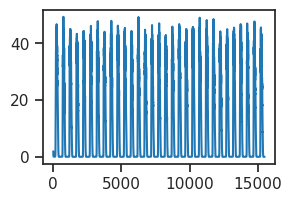

In [12]:
neuron_i = most_active_neurons[0]
plot(firing_rates[-1, :, neuron_i])

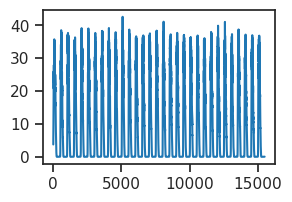

In [20]:
### Was: n_exp_p = 1e-6

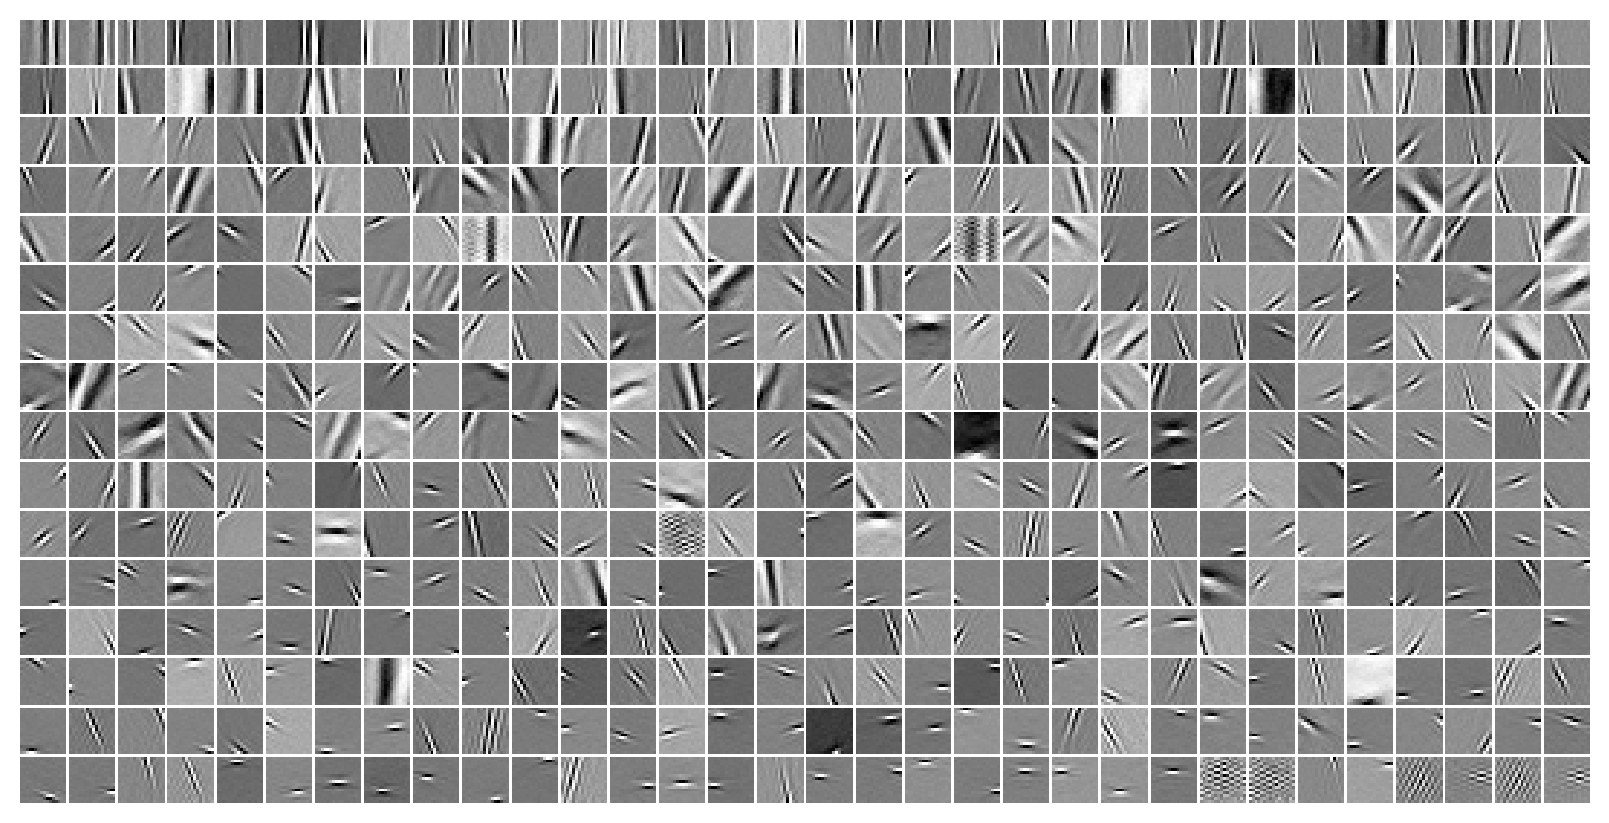

In [13]:
tr.model.show(order=most_active_neurons);

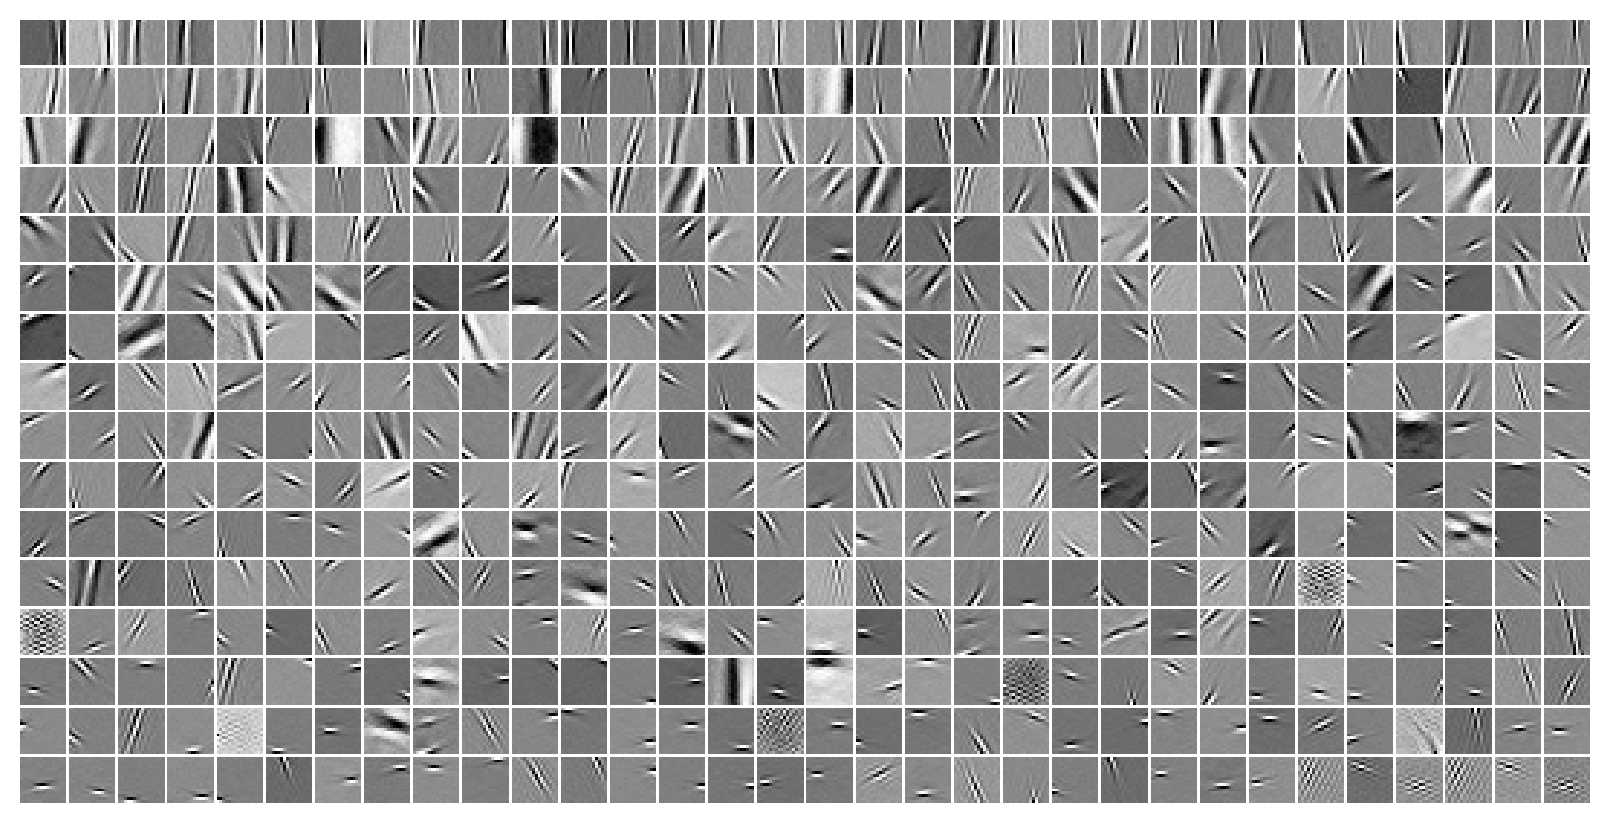

In [21]:
### Was: n_exp_p = 1e-6

In [17]:
which_neuron = 5

spks_high_contrast = tonp(output['samples'][-1, :, most_active_neurons[which_neuron]])
spks_low_contrast = tonp(output['samples'][0, :, most_active_neurons[which_neuron]])

spks_low_contrast.shape, spks_high_contrast.shape

((15500,), (15500,))

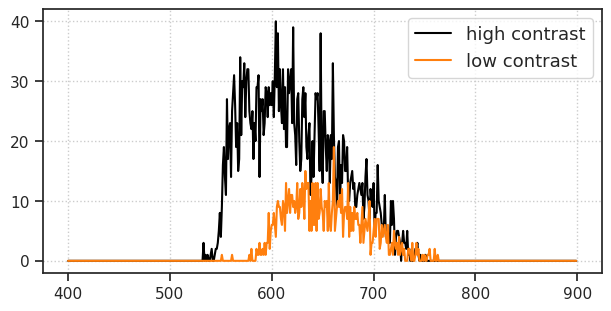

In [18]:
intvl = range(400, 900)

fig, ax = create_figure(1, 1, (6, 3))
ax.plot(intvl, spks_high_contrast[intvl], color='k', label='high contrast')
ax.plot(intvl, spks_low_contrast[intvl], color='C1', label='low contrast')
# ax.axvline(500, color='dimgrey', ls='--', label='stimulus onset')

ax.legend(fontsize=13)
ax.grid()

plt.show()

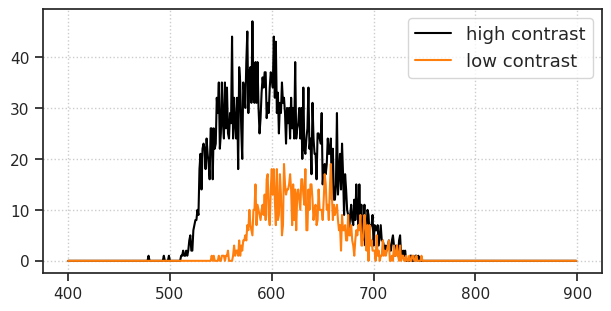

In [23]:
### Was: n_exp_p = 1e-6

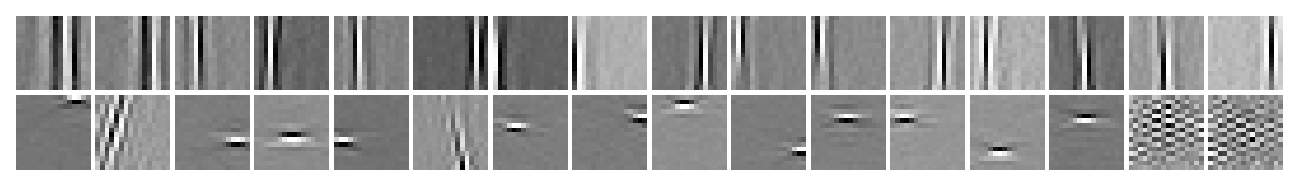

In [19]:
w = tonp(tr.model.layer.get_weight())
w = w.T.reshape(-1, 16, 16)

num = 16
num_skip = 6

x2p = np.concatenate([
    w[most_active_neurons[:num]],
    w[most_active_neurons[-num-num_skip:-num_skip]],
], axis=0)

plot_weights(x2p, nrows=2)
plt.show()

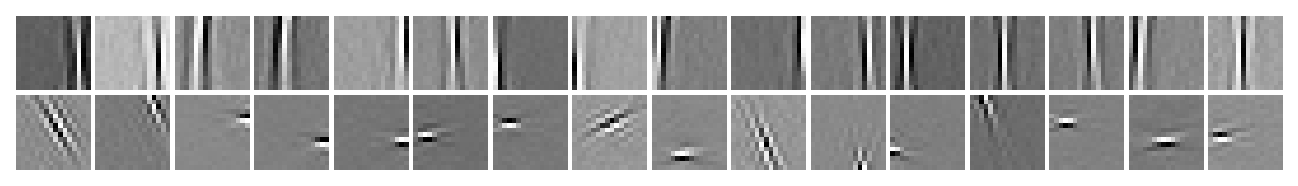

In [25]:
### Was: n_exp_p = 1e-6

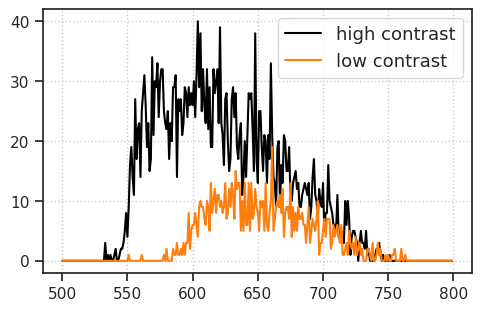

In [25]:
intvl = range(500, 800)

fig, ax = create_figure(1, 1, (4.7, 3))
ax.plot(intvl, spks_high_contrast[intvl], color='k', label='high contrast')
ax.plot(intvl, spks_low_contrast[intvl], color='C1', label='low contrast')
# ax.axvline(500, color='dimgrey', ls='--', label='stimulus onset')

ax.legend(fontsize=13)
ax.grid()

plt.show()

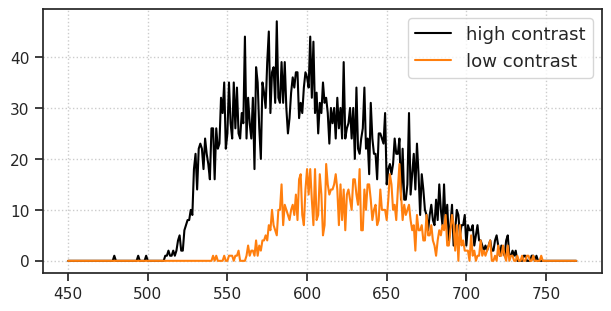

In [24]:
### Was: n_exp_p = 1e-6

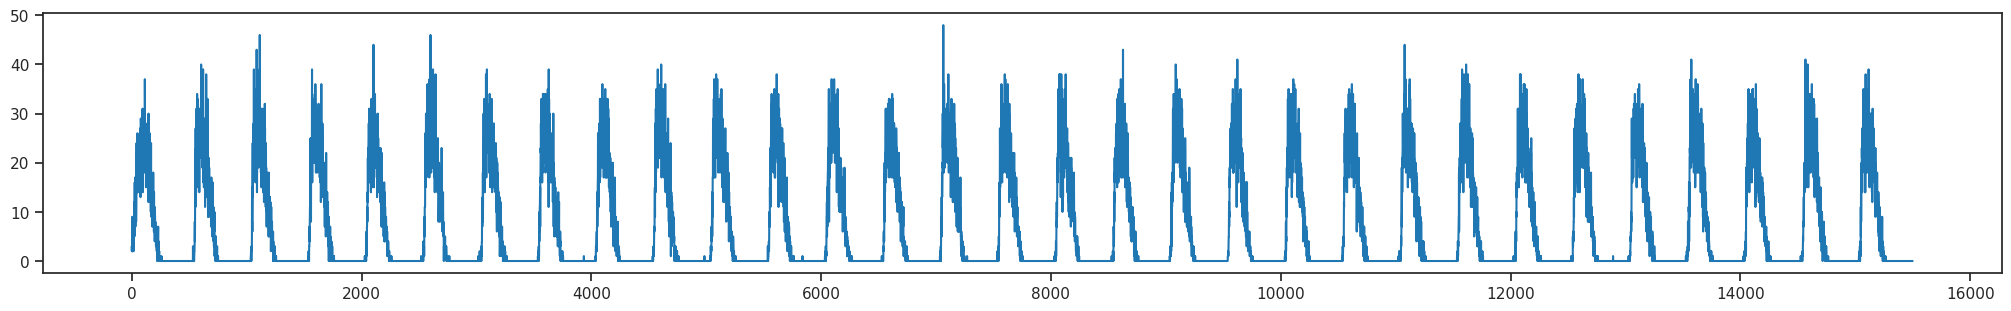

In [26]:
fig, ax = create_figure(1, 1, (20, 3))
plt.plot(spks_high_contrast);

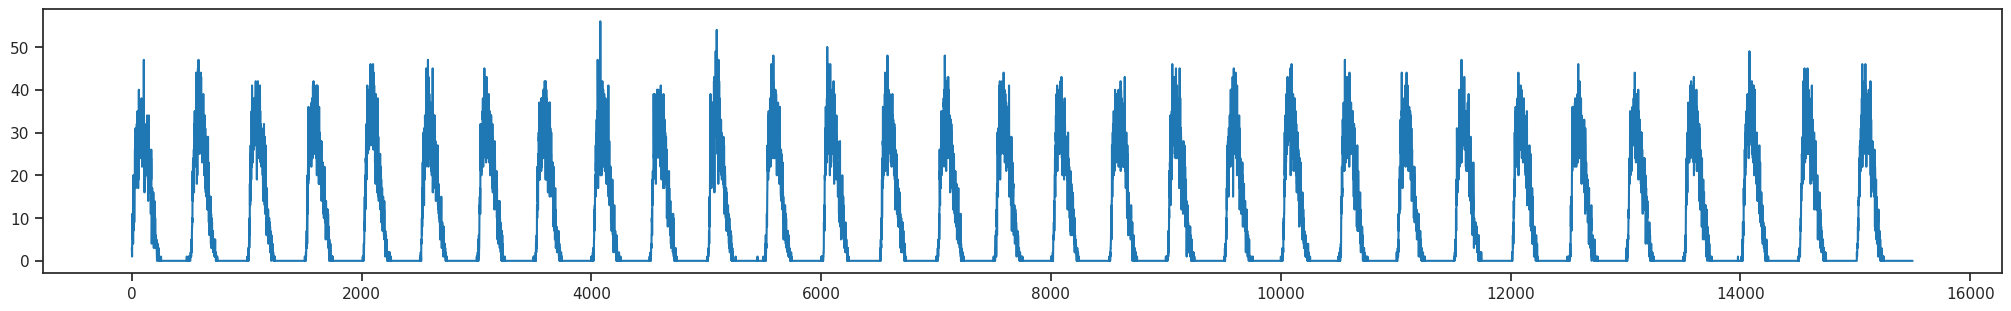

In [26]:
### Was: n_exp_p = 1e-6

### Trial analysis

Throw away the first 500 timepoints

In [27]:
data = spks_high_contrast[n_frames_for_full_cycle:]
data = data.reshape(-1, n_frames_for_full_cycle)
data.shape

(30, 500)

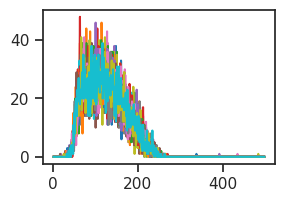

In [28]:
plt.plot(data.T);

In [29]:
def plot_mean_ci(data, xs=None):
    mean = np.mean(data, axis=0)
    sem = sp_stats.sem(data, axis=0)
    t_val = sp_stats.t.ppf(0.975, data.shape[0] - 1)
    ci = sem * t_val

    if xs is None:
        xs = np.arange(data.shape[1])
    plt.plot(xs, mean[xs], color='k')

    y1, y2 = mean - ci, mean + ci
    plt.fill_between(xs, y1[xs], y2[xs], alpha=0.5)
    plt.show()

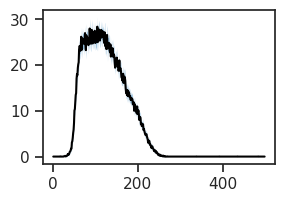

In [30]:
plot_mean_ci(data)

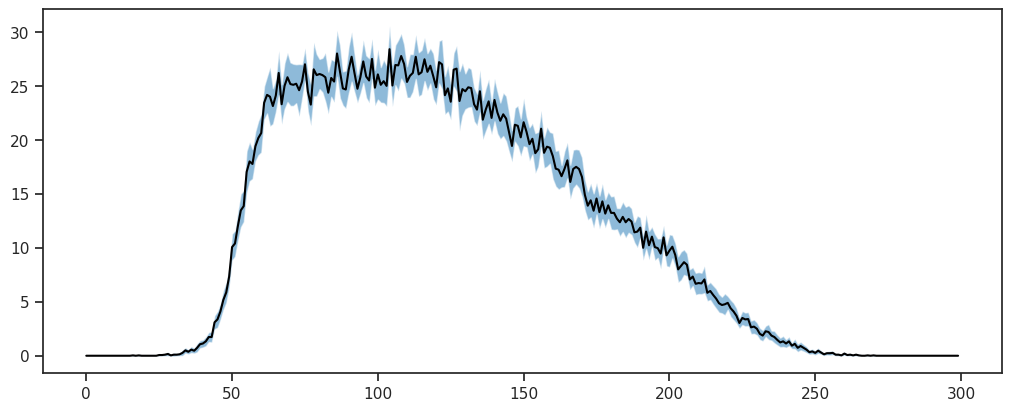

In [31]:
fig, ax = create_figure(1, 1, (10, 4))
plot_mean_ci(data, range(300))

### Now actual trials

In [35]:
n_trials_inner = 10
seq = range(n_frames_for_full_cycle * (n_trials_inner + 1))

print(seq)

range(0, 5500)

In [36]:
%%time

n_trials_outer = 20

data_all = []
for i in tqdm(range(n_trials_outer)):
    output = tr.model.xtract_ftr(
        feeder=feeder,
        seq=seq,
        return_extras=True,
    ).stack()

    spks_high_contrast = tonp(output['samples'][-1, :, most_active_neurons[which_neuron]])
    data = spks_high_contrast[n_frames_for_full_cycle:]
    data = data.reshape(-1, n_frames_for_full_cycle)
    data_all.append(data)

data_all = np.stack(data_all, axis=0)
data_all.shape

100%|███████████████████████████████████████████| 20/20 [03:30<00:00, 10.51s/it]

CPU times: user 3min 30s, sys: 40 ms, total: 3min 30s
Wall time: 3min 30s


(20, 10, 500)

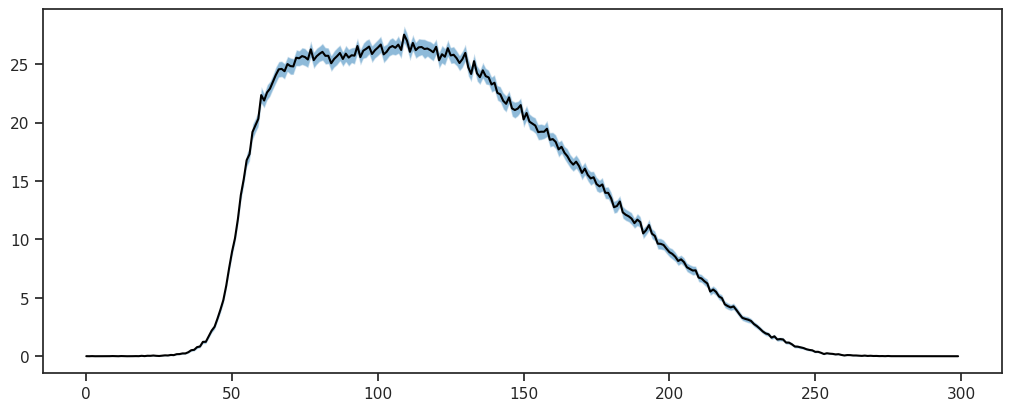

In [37]:
fig, ax = create_figure(1, 1, (10, 4))
plot_mean_ci(data_all.reshape(-1, n_frames_for_full_cycle), range(300))

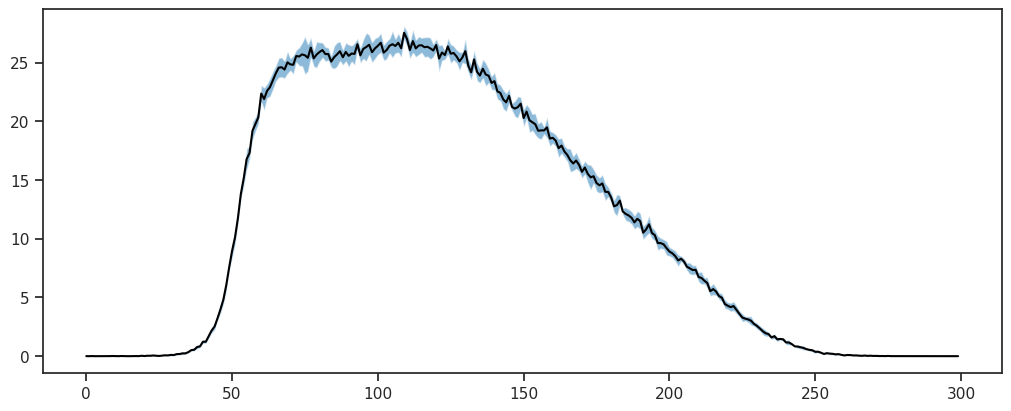

In [38]:
fig, ax = create_figure(1, 1, (10, 4))
plot_mean_ci(data_all.mean(0), range(300))

In [39]:
def plot_mu_sd(ax, data, xs=None):
    mu = np.mean(data, axis=0)
    sd = np.std(data, axis=0)

    if xs is None:
        xs = np.arange(data.shape[1])
    ax.plot(xs, mu[xs], color='k')

    y1, y2 = mu - sd, mu + sd
    ax.fill_between(xs, y1[xs], y2[xs], alpha=0.5)
    return

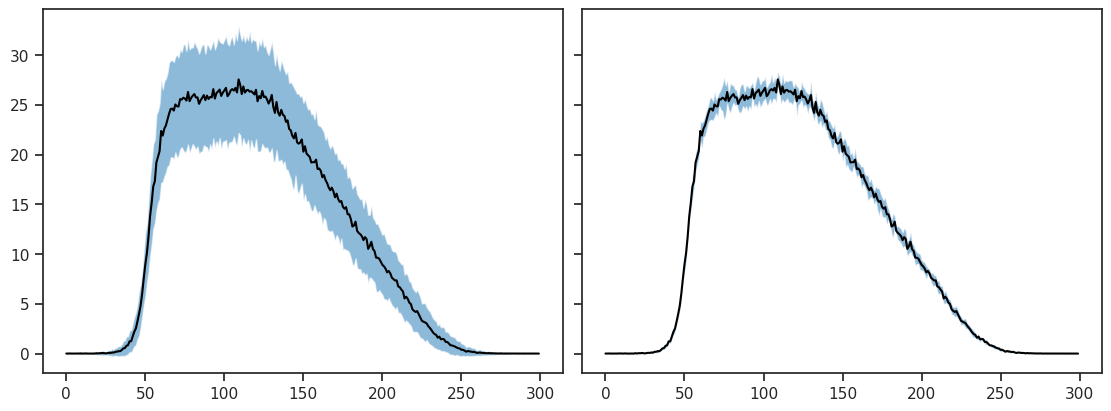

In [40]:
fig, axes = create_figure(1, 2, (11, 4), 'all', 'all')
plot_mu_sd(axes[0], data_all.reshape(-1, n_frames_for_full_cycle), range(300))
plot_mu_sd(axes[1], data_all.mean(0), range(300))

## Pick another neuron

In [41]:
which_neuron = 4

In [42]:
spks_high_contrast = tonp(output['samples'][-1, :, most_active_neurons[which_neuron]])
spks_low_contrast = tonp(output['samples'][0, :, most_active_neurons[which_neuron]])

spks_low_contrast.shape, spks_high_contrast.shape

((5500,), (5500,))

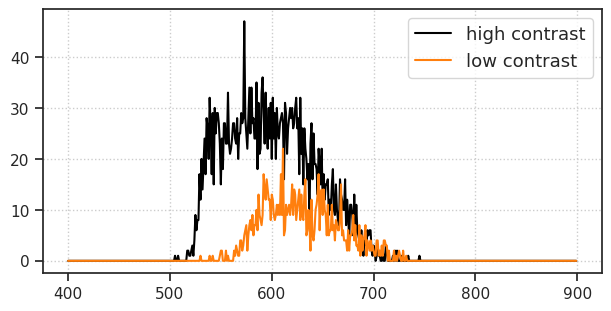

In [43]:
intvl = range(400, 900)

fig, ax = create_figure(1, 1, (6, 3))
ax.plot(intvl, spks_high_contrast[intvl], color='k', label='high contrast')
ax.plot(intvl, spks_low_contrast[intvl], color='C1', label='low contrast')
# ax.axvline(500, color='dimgrey', ls='--', label='stimulus onset')

ax.legend(fontsize=13)
ax.grid()

plt.show()

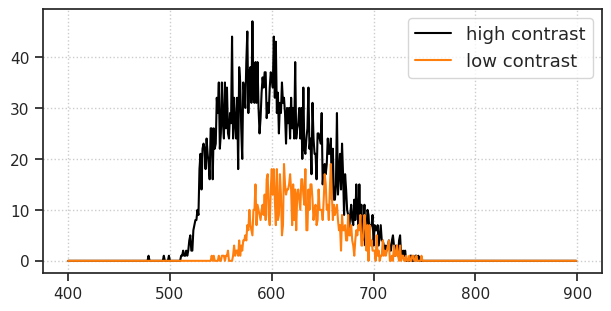

In [23]:
### Was: n_exp_p = 1e-6

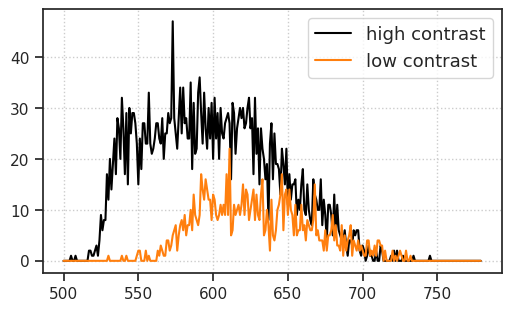

In [47]:
intvl = range(500, 780)

fig, ax = create_figure(1, 1, (5, 3))
ax.plot(intvl, spks_high_contrast[intvl], color='k', label='high contrast')
ax.plot(intvl, spks_low_contrast[intvl], color='C1', label='low contrast')
# ax.axvline(500, color='dimgrey', ls='--', label='stimulus onset')

ax.legend(fontsize=13)
ax.grid()

plt.show()

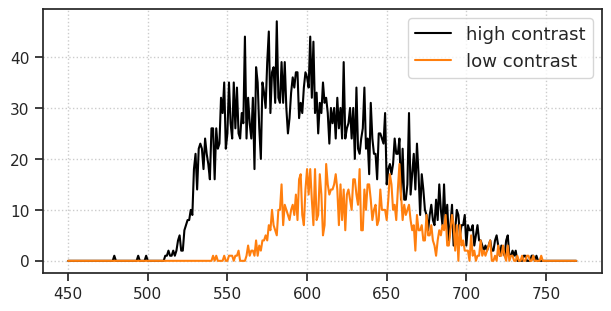

In [24]:
### Was: n_exp_p = 1e-6

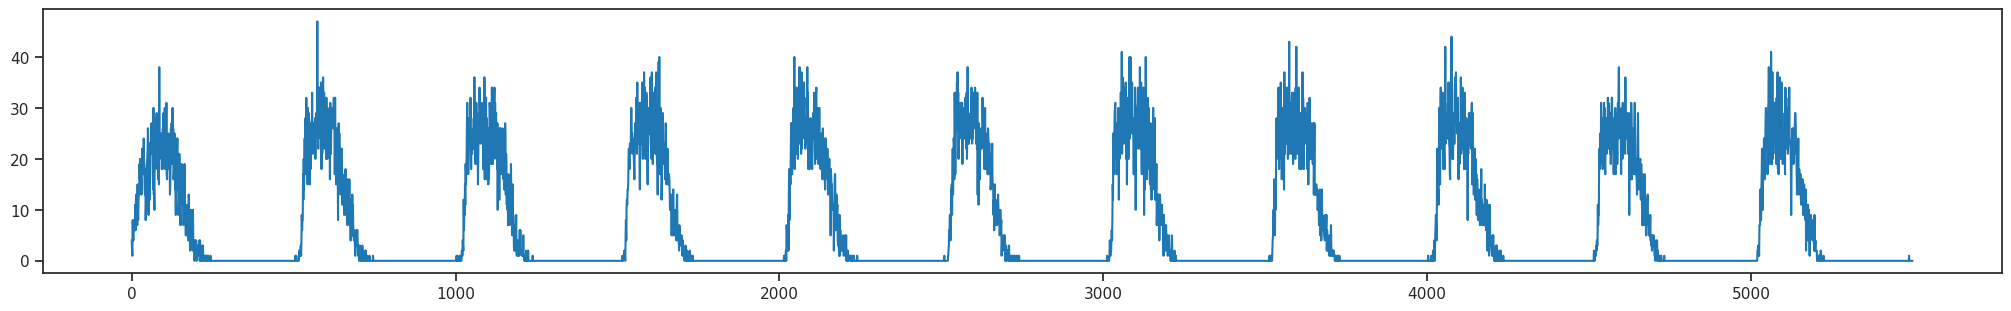

In [48]:
fig, ax = create_figure(1, 1, (20, 3))
plt.plot(spks_high_contrast);

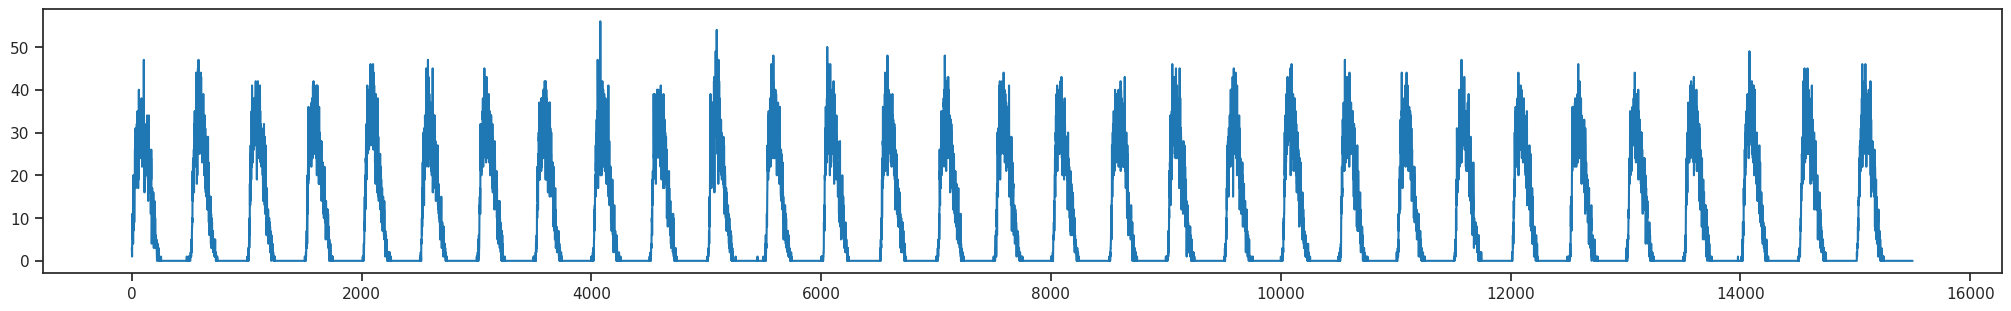

In [26]:
### Was: n_exp_p = 1e-6

### Trial analysis

Throw away the first 500 timepoints

In [49]:
data = spks_high_contrast[n_frames_for_full_cycle:]
data = data.reshape(-1, n_frames_for_full_cycle)
data.shape

(10, 500)

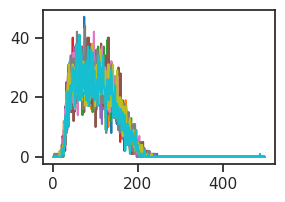

In [50]:
plt.plot(data.T);

In [51]:
def plot_mean_ci(data, xs=None):
    mean = np.mean(data, axis=0)
    sem = sp_stats.sem(data, axis=0)
    t_val = sp_stats.t.ppf(0.975, data.shape[0] - 1)
    ci = sem * t_val

    if xs is None:
        xs = np.arange(data.shape[1])
    plt.plot(xs, mean[xs], color='k')

    y1, y2 = mean - ci, mean + ci
    plt.fill_between(xs, y1[xs], y2[xs], alpha=0.5)
    plt.show()

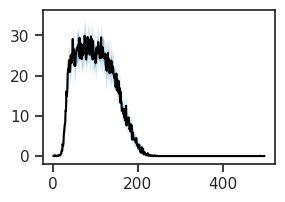

In [52]:
plot_mean_ci(data)

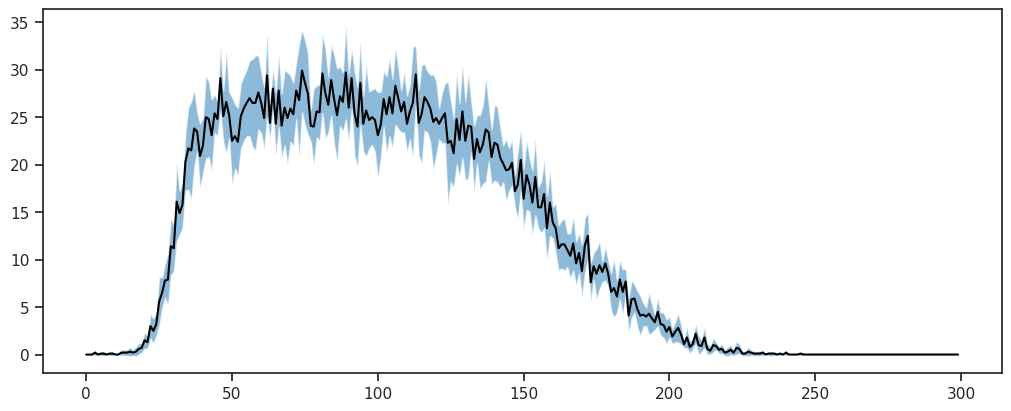

In [53]:
fig, ax = create_figure(1, 1, (10, 4))
plot_mean_ci(data, range(300))

### Now actual trials

In [54]:
n_trials_inner = 10
seq = range(n_frames_for_full_cycle * (n_trials_inner + 1))

print(seq)

range(0, 5500)

In [55]:
%%time

n_trials_outer = 20

data_all = []
for i in tqdm(range(n_trials_outer)):
    output = tr.model.xtract_ftr(
        feeder=feeder,
        seq=seq,
        return_extras=True,
    ).stack()

    spks_high_contrast = tonp(output['samples'][-1, :, most_active_neurons[which_neuron]])
    data = spks_high_contrast[n_frames_for_full_cycle:]
    data = data.reshape(-1, n_frames_for_full_cycle)
    data_all.append(data)

data_all = np.stack(data_all, axis=0)
data_all.shape

100%|███████████████████████████████████████████| 20/20 [03:30<00:00, 10.51s/it]

CPU times: user 3min 30s, sys: 56 ms, total: 3min 30s
Wall time: 3min 30s


(20, 10, 500)

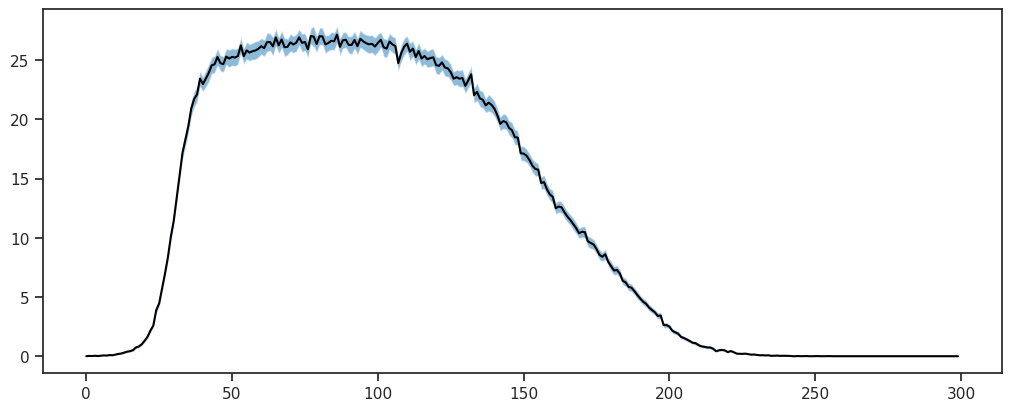

In [56]:
fig, ax = create_figure(1, 1, (10, 4))
plot_mean_ci(data_all.reshape(-1, n_frames_for_full_cycle), range(300))

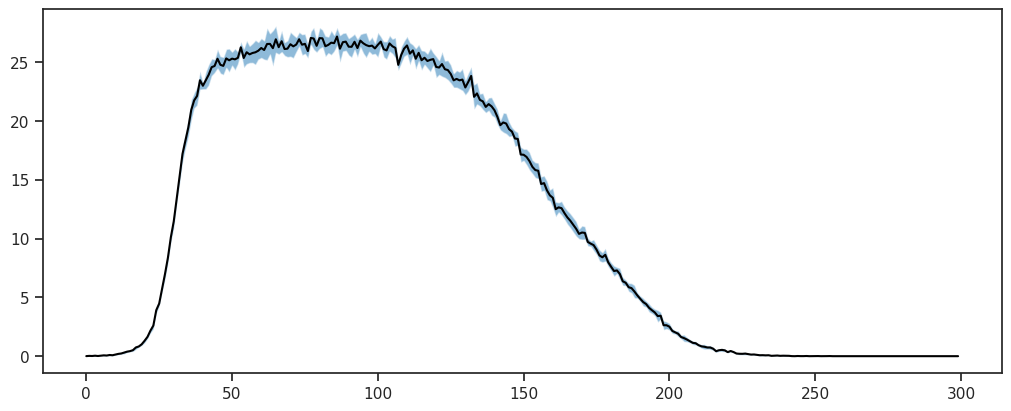

In [57]:
fig, ax = create_figure(1, 1, (10, 4))
plot_mean_ci(data_all.mean(0), range(300))

In [58]:
def plot_mu_sd(ax, data, xs=None):
    mu = np.mean(data, axis=0)
    sd = np.std(data, axis=0)

    if xs is None:
        xs = np.arange(data.shape[1])
    ax.plot(xs, mu[xs], color='k')

    y1, y2 = mu - sd, mu + sd
    ax.fill_between(xs, y1[xs], y2[xs], alpha=0.5)
    return

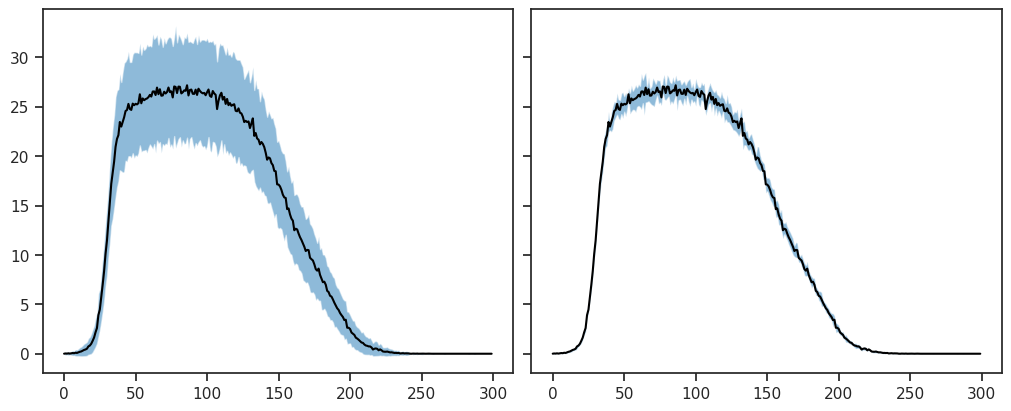

In [59]:
fig, axes = create_figure(1, 2, (10, 4), 'all', 'all')
plot_mu_sd(axes[0], data_all.reshape(-1, n_frames_for_full_cycle), range(300))
plot_mu_sd(axes[1], data_all.mean(0), range(300))

## Evaluate to make sure

In [60]:
print(tr.model.layer.n_exp)

tensor([19, 25, 34, 46, 57, 66, 71, 73, 74, 75, 75, 75, 75, 74, 74, 75],
       device='cuda:0', dtype=torch.int32)

In [4]:
### Was: t_stop = 0.05

tensor([17, 24, 34, 46, 57, 65, 70, 72, 74, 74, 75, 74, 74, 74, 74, 74],
       device='cuda:0', dtype=torch.int32)

In [9]:
### Was: p = 1e-6

tensor([23, 31, 43, 57, 70, 79, 84, 87, 88, 88, 89, 89, 89, 89, 88, 89],
       device='cuda:0', dtype=torch.int32)

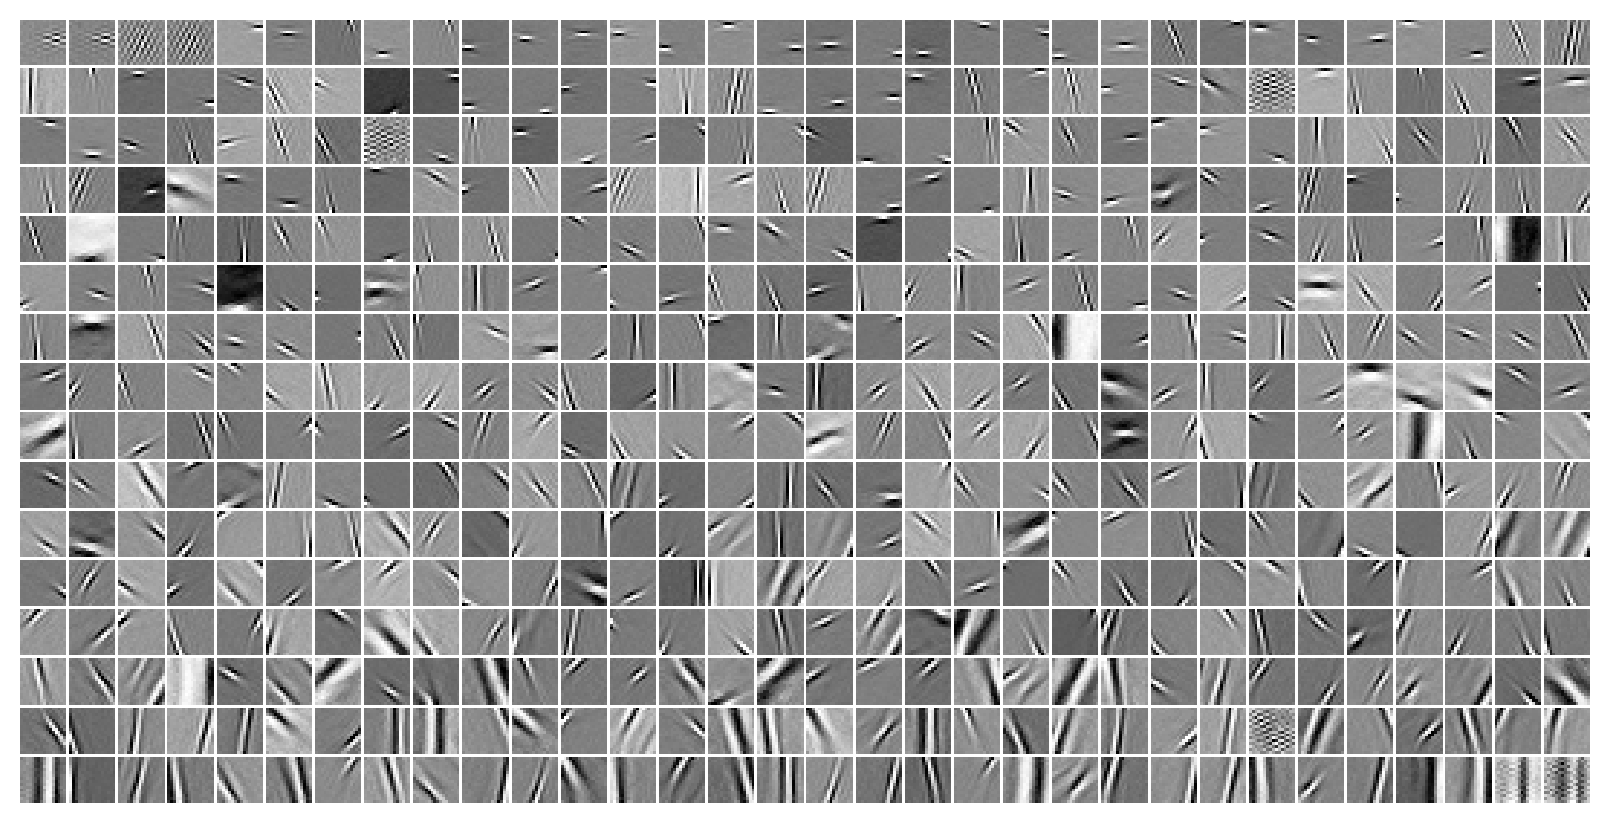

In [61]:
u0 = tonp(tr.model.layer.u_init.squeeze())
tr.model.show(order=np.argsort(u0));

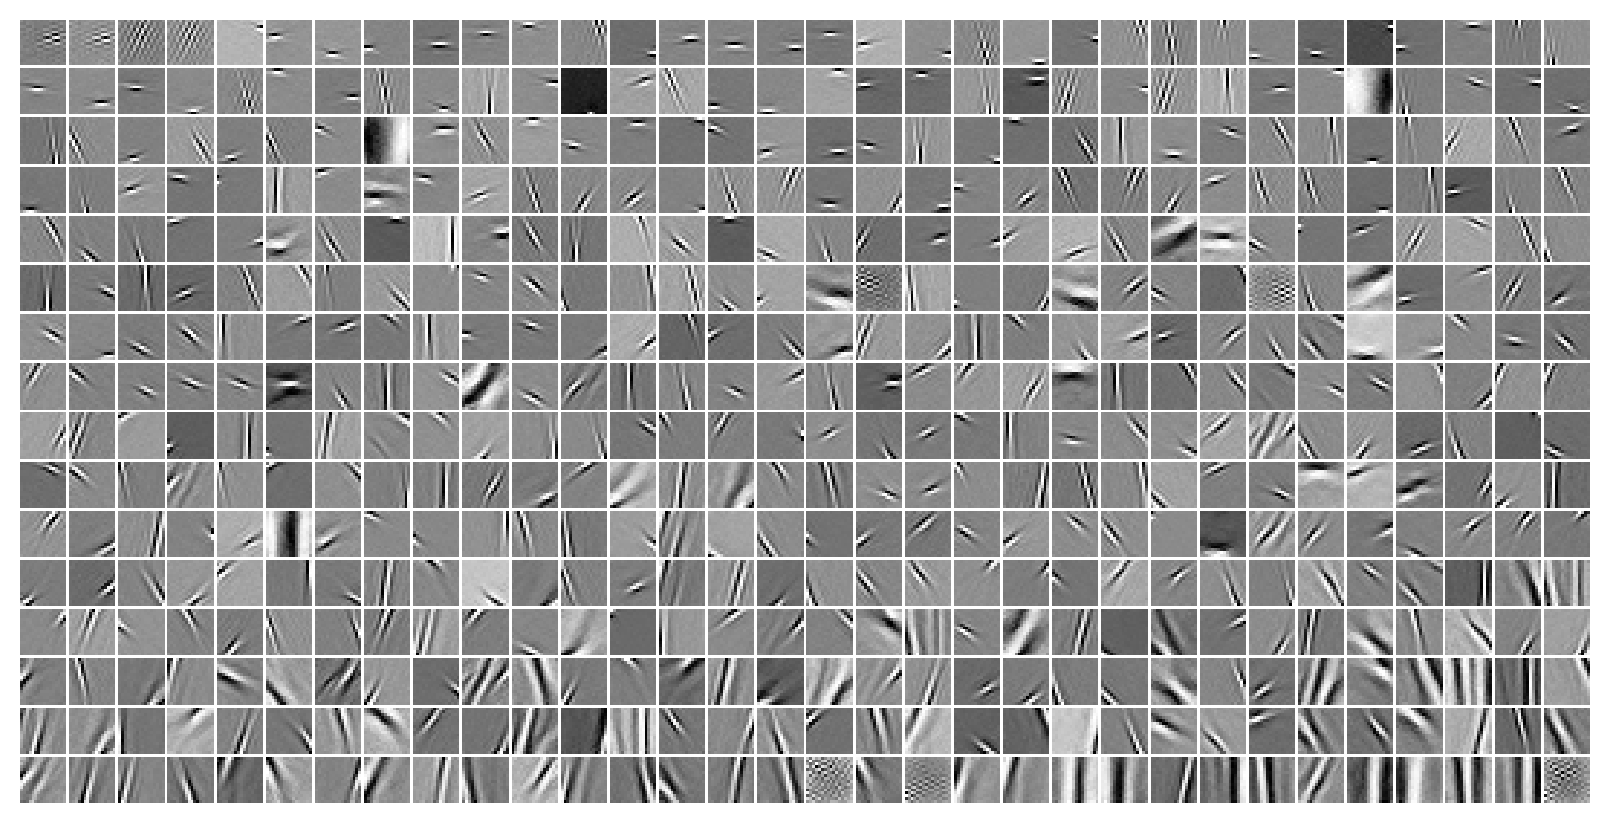

In [5]:
### Was: t_stop = 0.05

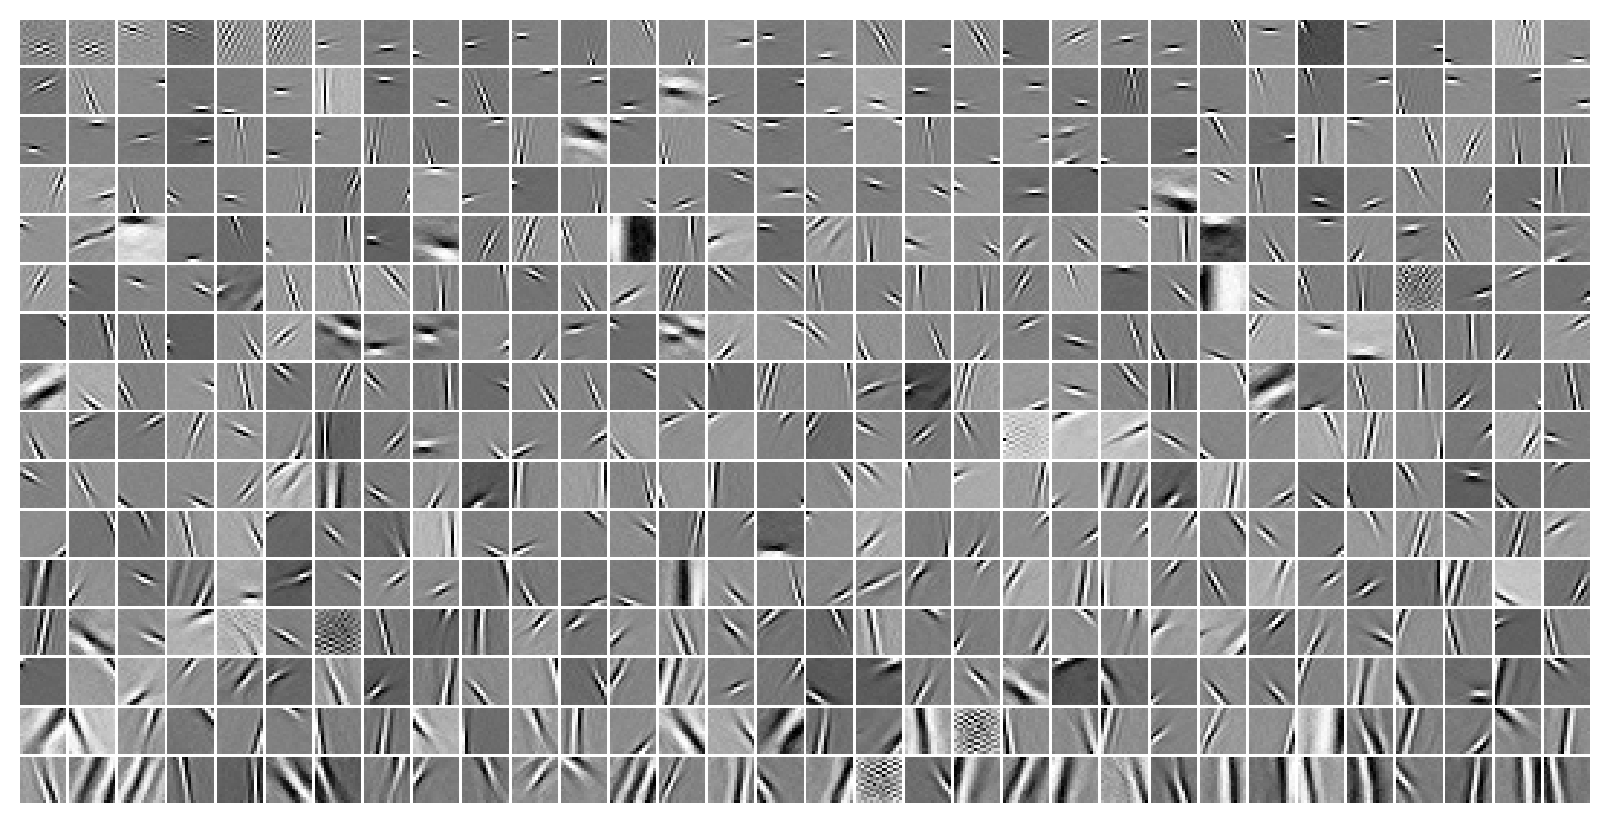

In [10]:
### Was: p = 1e-6

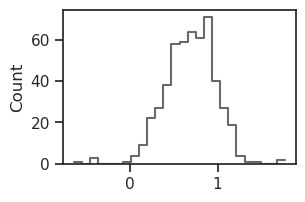

In [62]:
histplot(u0, color='dimgrey');

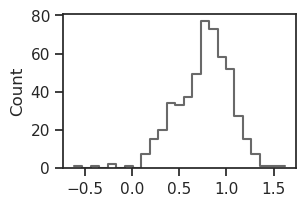

In [6]:
### Was: t_stop = 0.05

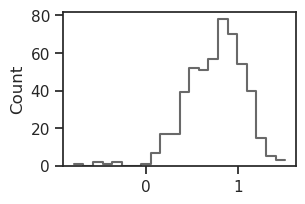

In [11]:
### Was: p = 1e-6

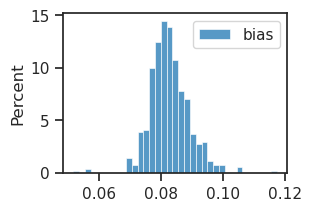

In [63]:
fig, ax = create_figure()

sns.histplot(tonp(tr.model.layer.log_bias.squeeze().exp()), label='bias', stat='percent',  ax=ax)
ax.legend()
plt.show()

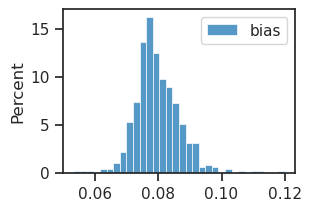

In [12]:
### Was: p = 1e-6

100%|███████████████████████████████████| 2/2 [00:41<00:00, 20.84s/it]


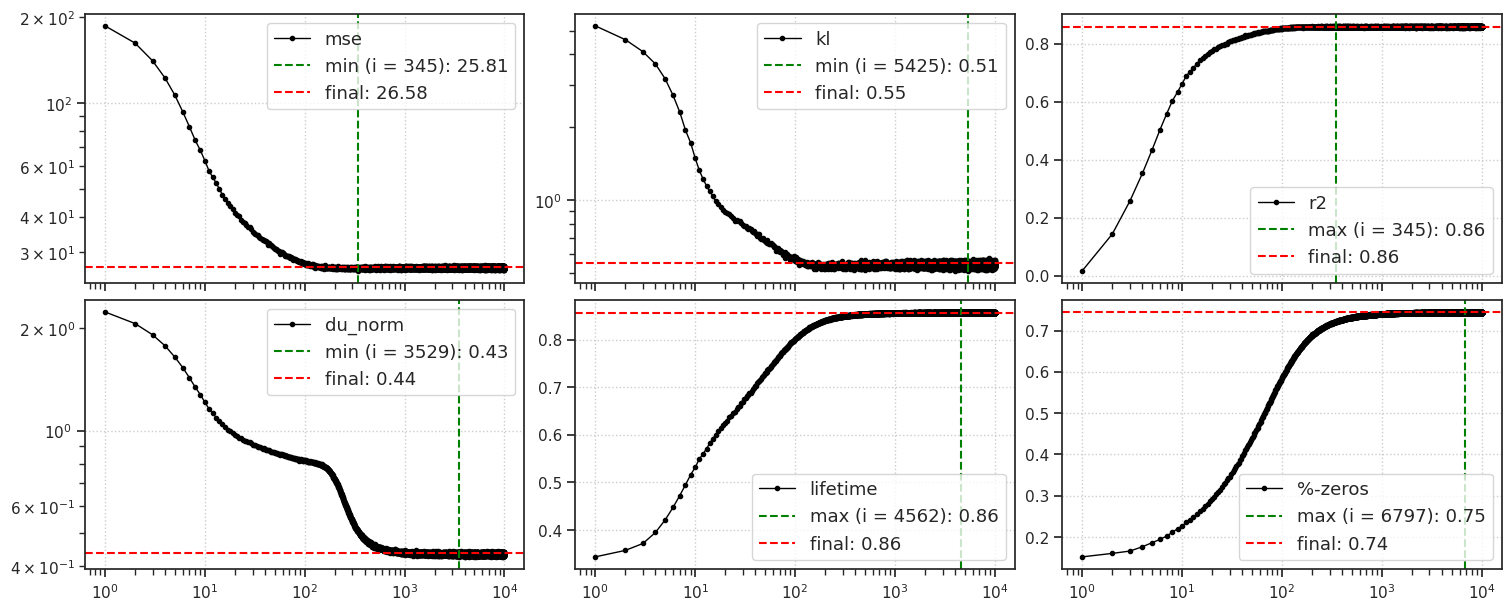

CPU times: user 50.3 s, sys: 2.56 s, total: 52.9 s
Wall time: 52.9 s


In [64]:
%%time

kws = dict(
    seq_total=10000,
    seq_batch_sz=1000,
    n_data_batches=2,
)
results = tr.analysis('vld', **kws)
_ = plot_convergence(results, color='k')

100%|███████████████████████████████████| 2/2 [01:03<00:00, 31.59s/it]


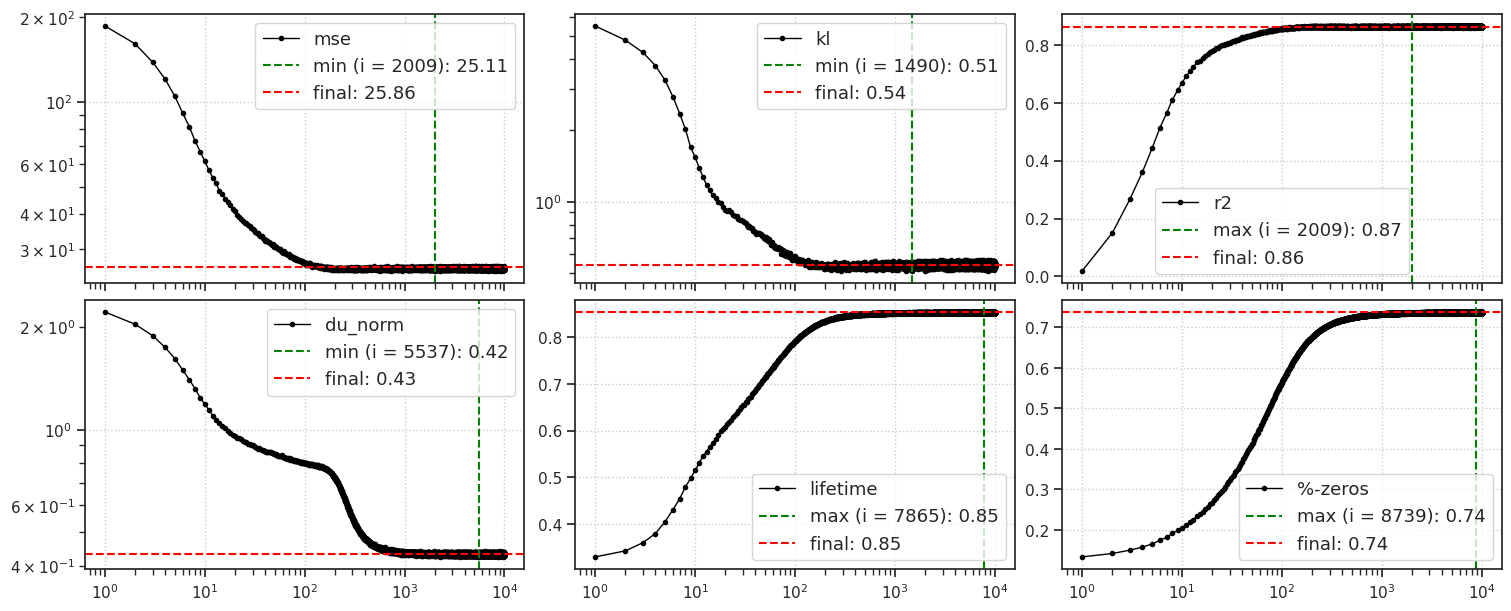

CPU times: user 1min 13s, sys: 2.72 s, total: 1min 16s
Wall time: 1min 16s


In [8]:
### Was: t_stop = 0.05

100%|███████████████████████████████████| 2/2 [00:41<00:00, 20.58s/it]


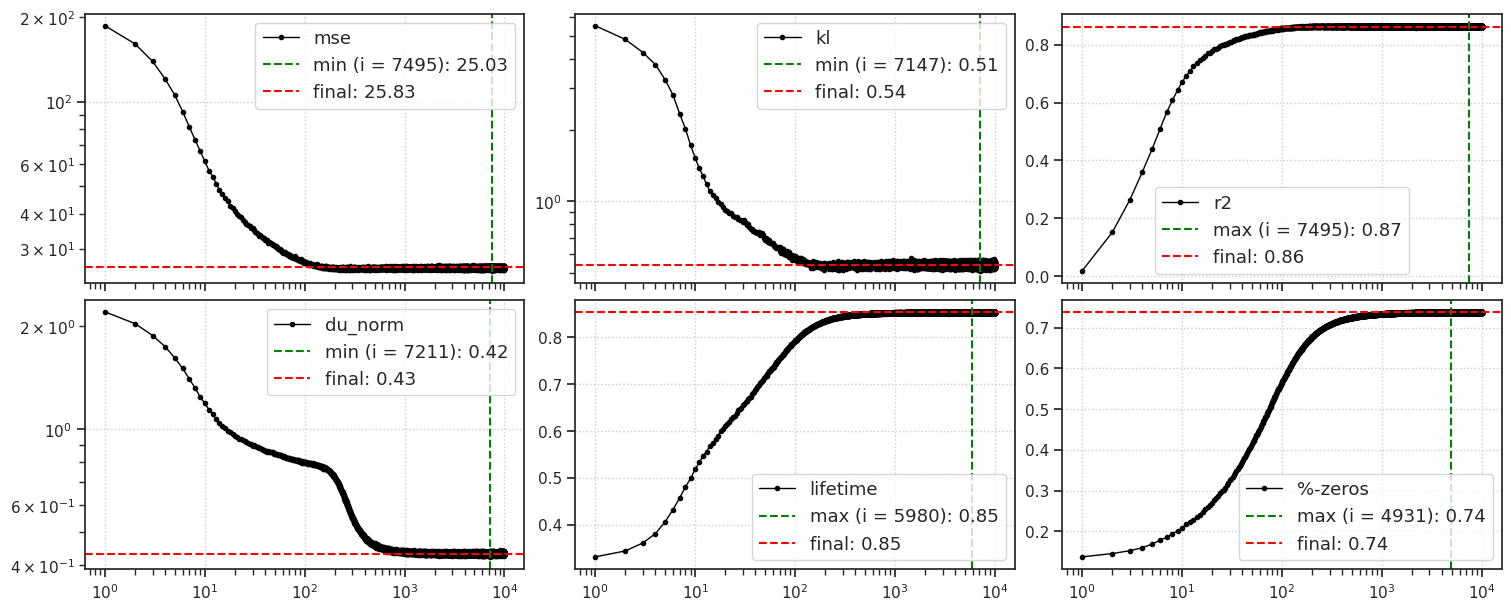

CPU times: user 49.4 s, sys: 2.76 s, total: 52.1 s
Wall time: 52.2 s


In [8]:
### Was: p = 1e-6

In [65]:
output = tr.model.xtract_ftr(
    feeder=tr.get_feeder(),
    seq=range(1000),
    return_extras=True,
).stack()

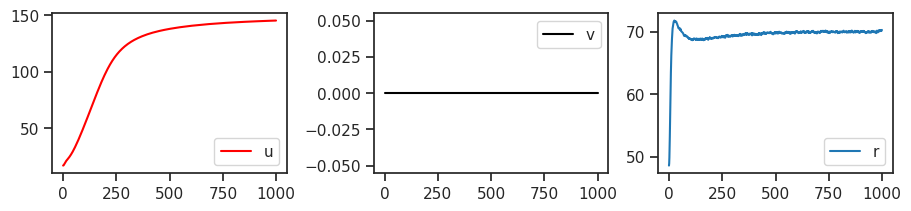

In [66]:
u_norm = tonp(torch.linalg.norm(output['u'], axis=-1).mean(0))
v_norm = tonp(torch.linalg.norm(output['v'], axis=-1).mean(0))
r_norm = tonp(torch.linalg.norm(torch.exp(output['u']), axis=-1).mean(0))

fig, axes = create_figure(1, 3)
axes[0].plot(u_norm, label='u', color='r')
axes[1].plot(v_norm, label='v', color='k')
axes[2].plot(r_norm, label='r')

add_legend(axes)
plt.show()

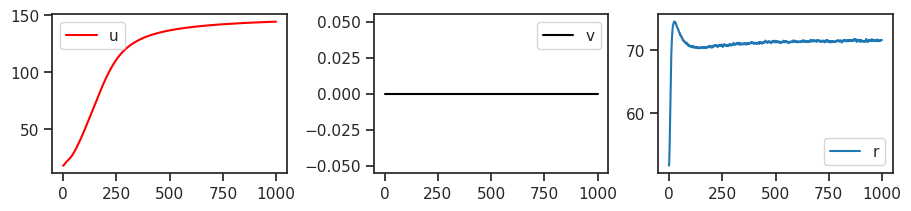

In [10]:
### Was: t_stop = 0.05

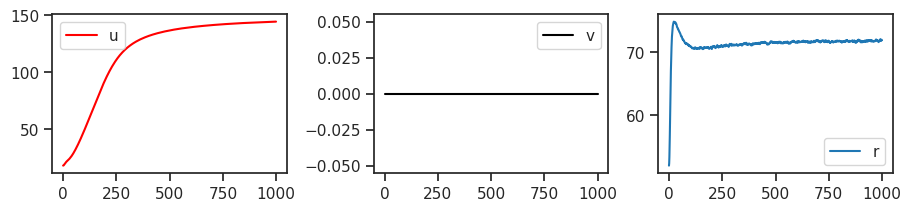

In [10]:
### Was: p = 1e-6